In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
import _nb_setup 

import numpy as np
import pandas as pd
import random
import time
import matplotlib.pyplot as plt
import networkx as nx
import kmapper as km
import kmapper.evaluate as evaluate
from sklearn import cluster
import sklearn
from kmapper import BCMO



In [2]:


# Users need to access https://people.csail.mit.edu/sumner/research/deftransfer/data.html to download Cat poses dataset and we use cat-reference.obj here.

def load_obj(obj_path):
    points = []
    i=0 
    with open(obj_path) as file:
        while 1:
            line = file.readline()

            if not line:
                break
            strs = line.split(" ")
            if strs[0] == "v":
                temp = []
                for j in range(1,len(strs)):                
                    if strs[j] != "":
                        temp.append(float(strs[j]))

                points.append(np.array(temp) )
        points = np.array(points)
        return points

cat_data = load_obj('cat-reference.obj')

def rotation_matrix_x(angle):
    angle = np.radians(angle)
    return np.array([
        [1, 0, 0],
        [0, np.cos(angle), -np.sin(angle)],
        [0, np.sin(angle), np.cos(angle)]
    ])

def rotation_matrix_y(angle):
    angle = np.radians(angle)
    return np.array([
        [np.cos(angle), 0, np.sin(angle)],
        [0, 1, 0],
        [-np.sin(angle), 0, np.cos(angle)]
    ])

def rotation_matrix_z(angle):
    angle = np.radians(angle)
    return np.array([
        [np.cos(angle), -np.sin(angle), 0],
        [np.sin(angle), np.cos(angle), 0],
        [0, 0, 1]])



In [ ]:
mapper = km.D_Mapper(verbose=0)
data = cat_data
Projected_data = mapper.fit_transform(data)

In [4]:
import numpy as np
import sklearn

@km.dmapper_objective
def objective_function_DMapper(n, a):
    projected_data = Projected_data
    cover = km.D_Cover(n_cubes=n, alpha=a, max_iter=100000, n_init=10, verbose=0)
    graph = mapper.map(
        projected_data, data,
        clusterer=sklearn.cluster.DBSCAN(eps=0.1, min_samples=5),
        cover=cover,
    )
    sc_adj = evaluate.compute_SC_adj(
        data, projected_data, graph,
        km.D_Cover(n_cubes=n, alpha=a, max_iter=100000, n_init=10, verbose=0),
        type='d',
        cluster=sklearn.cluster.DBSCAN(eps=0.1, min_samples=5),
    )
    return sc_adj


def run_bcmo_once(run_id):
    return km.run_bcmo(
        objective_fn=objective_function_DMapper,
        bounds=[(7, 15), (0.01, 0.1)],
        NP=20,
        gen=10,
        run_id=run_id,
        output="cat_BCMO.txt",
    )


In [ ]:
run_bcmo_once(1)

100%|██████████| 100/100


SC:0.2087666549
SC_norm:0.60438332745
TSR:0.14285714285714285
SC_adj:0.37362023515357146


100%|██████████| 100/100


SC:-0.01764238900204941
SC_norm:0.4911788054989753
TSR:0.2
SC_adj:0.3455894027494877


100%|██████████| 100/100


...

100%|██████████| 100/100


SC:-0.020112145081243583
SC_norm:0.4899439274593782
TSR:0.2
SC_adj:0.3449719637296891


100%|██████████| 100/100


SC:0.0252035165291
SC_norm:0.51260175826455
TSR:1.0
SC_adj:0.756300879132275


(array([ 9.02000671,  0.0108389 , -0.75630088]), 0.756300879132275)

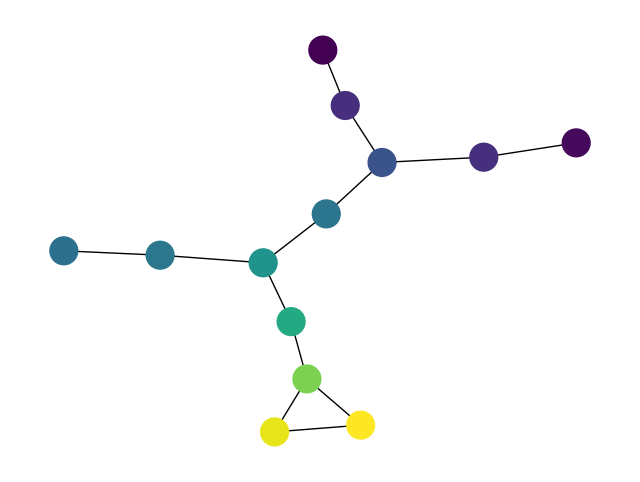

100%|██████████| 100/100


SC:0.0252035165291
SC_norm:0.51260175826455
TSR:1.0
SC_adj:0.756300879132275


In [ ]:
km.auto_seed()
mapper = km.D_Mapper(verbose=0)
data = cat_data

projected_data = mapper.fit_transform(data)
n = 9
a =  0.0108

cover = km.D_Cover(n_cubes = n, alpha = a,max_iter=100000,n_init=10,verbose=0)
graphD = mapper.map(
    projected_data,
    data,
    clusterer = sklearn.cluster.DBSCAN(eps=0.1, min_samples=5),
    cover= cover
)
interval_table_1 = cover.interval_table

color_list1 = []
for i in range(len(graphD['nodes'])):
    index_list = [l for l in graphD['nodes'].values()][i]
    color = np.mean(projected_data[index_list])
    color_list1.append(color)
G1 = km.adapter.to_networkx(graphD)
pos = nx.kamada_kawai_layout(G1)

fig, ax = plt.subplots(figsize=(8, 6))
nx.draw(G1, pos=pos, node_color=color_list1, node_size=400, cmap='viridis', ax=ax)

sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=min(color_list1), vmax=max(color_list1)))
sm.set_array([])

plt.axis('off')
plt.show()

SC_adj = evaluate.compute_SC_adj(data, projected_data, graphD, km.D_Cover(n_cubes = n, alpha = a,max_iter=100000,n_init=10,verbose=0), type = 'd'
                                 , cluster = sklearn.cluster.DBSCAN(eps=0.1, min_samples=5))

# BCMO Convergence

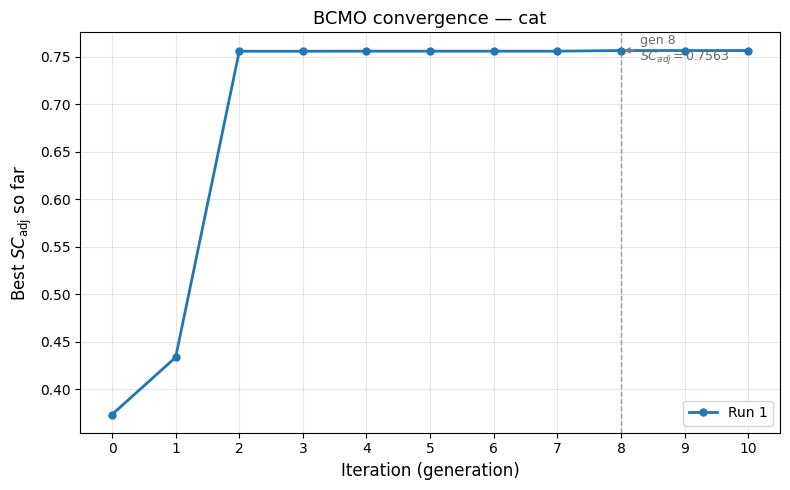

Saved → cat_convergence.png


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("cat_history.csv")

fig, ax = plt.subplots(figsize=(8, 5))

for run_id, grp in df.groupby("run_id"):
    grp = grp.sort_values("gen")
    xs, ys = grp["gen"].to_numpy(), grp["best_sc_adj"].to_numpy()

    conv_mask = ys == ys[-1]
    conv_gen  = xs[conv_mask][0]

    ax.plot(xs, ys, linewidth=2, marker="o", markersize=5, label=f"Run {run_id}")

    ax.axvline(conv_gen, color="gray", linestyle="--", linewidth=1, alpha=0.7)
    ax.annotate(
        f"gen {conv_gen}\n$SC_{{adj}}={ys[-1]:.4f}$",
        xy=(conv_gen, ys[conv_mask][0]),
        xytext=(conv_gen + 0.3, ys[conv_mask][0] - 0.01),
        fontsize=9,
        arrowprops=dict(arrowstyle="->", color="gray"),
        color="dimgray",
    )

ax.set_xlabel("Iteration (generation)", fontsize=12)
ax.set_ylabel(r"Best $SC_{\mathrm{adj}}$ so far", fontsize=12)
ax.set_title("BCMO convergence — cat", fontsize=13)
ax.set_xticks(sorted(df["gen"].unique()))
ax.grid(alpha=0.3)
ax.legend(loc="lower right")

plt.tight_layout()
plt.savefig("cat_convergence.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved → cat_convergence.png")
